# Week 2 — Bloch Sphere: Visualization and Phases

Practice notebook for Week 2 of the Quantum Computing study plan.

Goals:
- Visualize single-qubit states on the Bloch sphere with `plot_bloch_vector` / `plot_bloch_multivector`
- Build arbitrary states with the $U(\theta,\varphi,\lambda)$ gate
- Experimentally verify (in ideal simulation) the physical distinction between relative phase (observable, moves $\vec n$) and global phase (unobservable, $\vec n$ invariant)

Theory reference: hand derivation of the parametrization $|\psi\rangle=\cos(\theta/2)|0\rangle+e^{i\varphi}\sin(\theta/2)|1\rangle$ and of the Bloch vector $\vec n=\langle\psi|\vec\sigma|\psi\rangle=(\sin\theta\cos\varphi,\sin\theta\sin\varphi,\cos\theta)$ — see personal study notes, session of 2026-07-29.

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_vector, plot_bloch_multivector

## State $|0\rangle$: Bloch vector computed by hand

$|0\rangle$ corresponds to $\theta=0$ in the parametrization (any $\varphi$, irrelevant at the pole). From the formula:

$$\vec n = (\sin 0\cos\varphi,\ \sin 0\sin\varphi,\ \cos 0) = (0,0,1)$$

We pass the coordinates directly to `plot_bloch_vector` (low-level function: takes already-computed $(n_x,n_y,n_z)$).

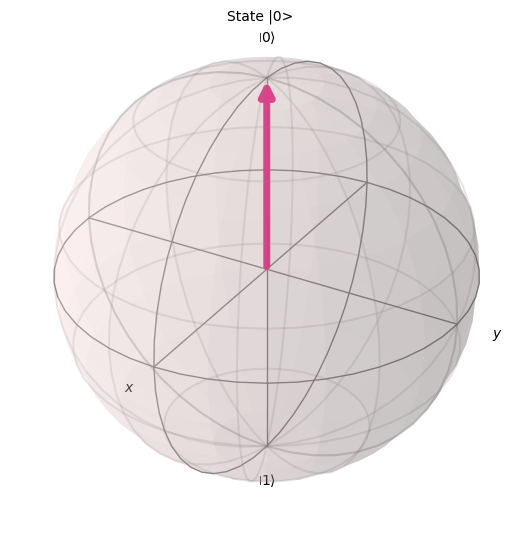

In [2]:
plot_bloch_vector([0, 0, 1], title="State |0>")

## Arbitrary state with the $U(\theta,\varphi,\lambda)$ gate

$$U(\theta,\varphi,\lambda) = \begin{pmatrix} \cos(\theta/2) & -e^{i\lambda}\sin(\theta/2) \\ e^{i\varphi}\sin(\theta/2) & e^{i(\varphi+\lambda)}\cos(\theta/2) \end{pmatrix}$$

Applied to $|0\rangle$ (Qiskit's default initial state), the first column gives:

$$U(\theta,\varphi,\lambda)|0\rangle = \cos(\theta/2)|0\rangle + e^{i\varphi}\sin(\theta/2)|1\rangle$$

— $\lambda$ does not appear (it only acts on the $|1\rangle$ component of the input, which is absent here). We build $\theta=\pi/2,\ \varphi=\pi/2,\ \lambda=0$: expected state $|{+i}\rangle=\frac{1}{\sqrt2}(|0\rangle+i|1\rangle)$, Bloch vector $(0,1,0)$.

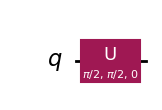

In [3]:
qc = QuantumCircuit(1)
qc.u(np.pi/2, np.pi/2, 0, 0)
qc.draw('mpl')

In [4]:
state = Statevector.from_instruction(qc)
print(state)

Statevector([7.07106781e-01+0.j        , 4.32978028e-17+0.70710678j],
            dims=(2,))


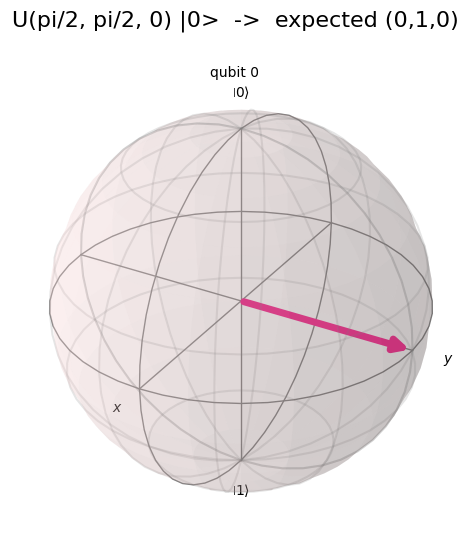

In [5]:
plot_bloch_multivector(state, title="U(pi/2, pi/2, 0) |0>  ->  expected (0,1,0)")

## Relative phase: change $\varphi$, the vector moves

Same $\theta=\pi/2$ (same 50/50 superposition in magnitude), but $\varphi=0$ instead of $\pi/2$. Expected $|+\rangle=\frac{1}{\sqrt2}(|0\rangle+|1\rangle)$, vector $(1,0,0)$: relative phase **is** observable, it moves $\vec n$ along the equator.

In [6]:
qc2 = QuantumCircuit(1)
qc2.u(np.pi/2, 0, 0, 0)
state2 = Statevector.from_instruction(qc2)
print(state2)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


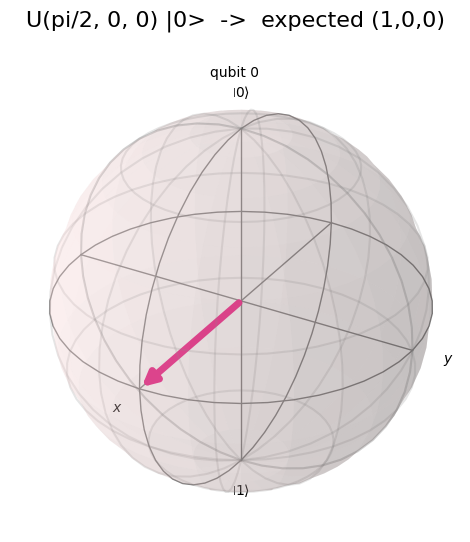

In [7]:
plot_bloch_multivector(state2, title="U(pi/2, 0, 0) |0>  ->  expected (1,0,0)")

## Global phase: the vector does NOT move

We multiply `state2` by a global phase factor $e^{i\gamma}$, $\gamma=\pi/3$. The printed numerical amplitudes change (each component rotates in the complex plane), but **moduli and relative phase stay identical** — so $\vec n$ must remain $(1,0,0)$. Direct verification of Postulate 1 (physical state = ray, not vector).

In [8]:
global_phase = np.pi/3
state2_global = Statevector(np.exp(1j*global_phase) * state2.data)
print("state2       :", state2)
print("state2_global:", state2_global)

state2       : Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
state2_global: Statevector([0.35355339+0.61237244j, 0.35355339+0.61237244j],
            dims=(2,))


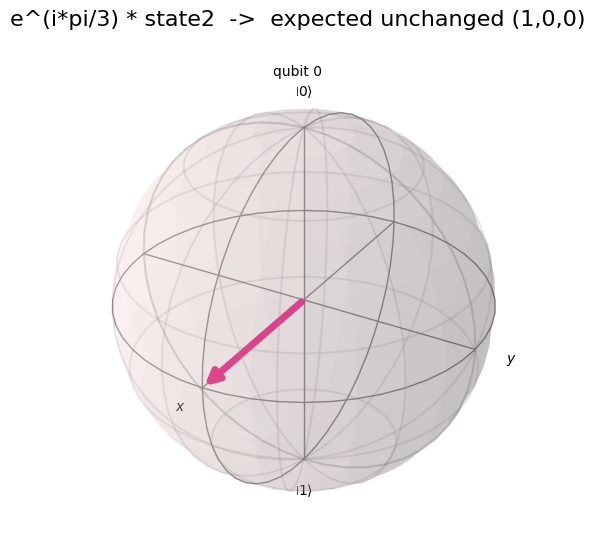

In [9]:
plot_bloch_multivector(state2_global, title="e^(i*pi/3) * state2  ->  expected unchanged (1,0,0)")

## Conclusions

- `plot_bloch_vector` draws already-known $(n_x,n_y,n_z)$ coordinates; `plot_bloch_multivector` automatically computes $\vec n$ from a `Statevector` (one sphere per qubit, via partial trace if the system has more than one qubit — for entangled states the individual-qubit vectors end up inside the sphere, a preview of the Bloch ball for mixed states, Phase 3).
- The $U(\theta,\varphi,\lambda)$ gate applied to $|0\rangle$ exactly reproduces the hand-derived Bloch parametrization; $\lambda$ only becomes relevant when composing multiple gates in sequence (preview: ZYZ decomposition, Week 3).
- Experimentally confirmed: relative phase is observable (moves $\vec n$), global phase is not observable ($\vec n$ invariant) — consistent with Postulate 1.